# Automatic Differentiation

Automatic differentiation augments a computation with another computation that propagates derivatives through the same primitive operations. It applies the chain rule to the computational graph exactly, up to floating-point arithmetic.

## Computational graphs

A computational graph is a directed acyclic graph (or DAG) that encodes the computation of a multivariate function.
We are going to use two types of nodes in the graph.
Tensor nodes (i.e., numerical arrays) are represented by circles.
Operation nodes (i.e., mathematical operations) are represented by shaded boxes.
The mathematical operators we consider here are *primitive* operators: operations treated as indivisible at the chosen level of description.
Which operators are primitive depends on where we build the computational graph.
For example, if we are working directly at the level of the compiler of a programming language, the primitives are just the basic arithmetic operations (e.g., addition, multiplication).
At a higher level, primitives can include matrix multiplication, trigonometric functions, exponentials, and power functions.
Because we are working within Python, we will use the second approach.
This is the level exposed by libraries such as `PyTorch` and `JAX`.

Here is an example. Consider the following function:

$$
f(x) = x^2 + x
$$

Here is a good implementation of this function in Python:

```python
def f(x):
    a = x ** 2
    b = a + x
    return b
```

The implementation names the intermediate results `a` and `b`. The node `sqr` below computes the square, and `add` computes the sum. When `x` is a tensor, libraries such as `PyTorch` and `JAX` record a computational graph of this form:



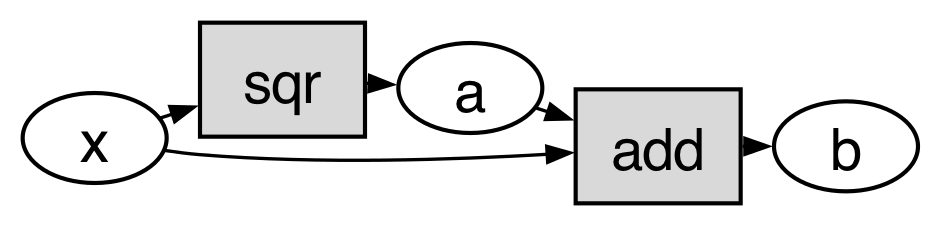

In [1]:
import base64

import graphviz
from IPython.display import display


def new_graph(rankdir="LR"):
    return graphviz.Digraph(
        graph_attr={
            "rankdir": rankdir,
            "bgcolor": "transparent",
            "margin": "0.02",
            "ordering": "out",
            "nodesep": "0.12",
            "ranksep": "0.08",
        },
        node_attr={
            "fontname": "DejaVu Sans",
            "fontsize": "14",
            "color": "black",
            "fontcolor": "black",
            "penwidth": "1.0",
            "margin": "0",
        },
        edge_attr={
            "color": "black",
            "penwidth": "0.8",
            "arrowsize": "0.55",
        },
    )


tensor_node = {
    "shape": "ellipse",
    "style": "filled",
    "fillcolor": "white",
    "fixedsize": "true",
    "width": "0.48",
    "height": "0.30",
}
operation_node = {
    "shape": "box",
    "style": "filled",
    "fillcolor": "gray85",
    "fixedsize": "true",
    "width": "0.55",
    "height": "0.38",
}
derivative_tensor_node = {
    "shape": "ellipse",
    "style": "dashed,filled",
    "fillcolor": "gray90",
    "fixedsize": "true",
    "width": "0.58",
    "height": "0.30",
}
derivative_output_node = {
    **derivative_tensor_node,
    "width": "1.05",
}
derivative_operation_node = {
    "shape": "box",
    "style": "dashed,filled",
    "fillcolor": "gray75",
    "fixedsize": "true",
    "width": "0.72",
    "height": "0.40",
}
derivative_edge = {
    "style": "dashed",
    "color": "black",
    "penwidth": "1.0",
    "arrowsize": "0.55",
}


def display_graph(graph):
    """Display vector web output and print-compatible PDF/PNG fallbacks."""
    svg = graph.pipe(format="svg").decode("utf-8")
    pdf = graph.pipe(format="pdf")
    graph.graph_attr["dpi"] = "300"
    try:
        png = graph.pipe(format="png")
    finally:
        graph.graph_attr.pop("dpi", None)
    display(
        {
            "image/svg+xml": svg,
            "application/pdf": base64.b64encode(pdf).decode("ascii"),
            "image/png": base64.b64encode(png).decode("ascii"),
        },
        raw=True,
    )


g = new_graph()

g.node('x', **tensor_node)
g.node('a', **tensor_node)
g.node('b', **tensor_node)
g.node('sqr', **operation_node)
g.node('add', **operation_node)

g.edge('x', 'sqr')
g.edge('sqr', 'a')
g.edge('a', 'add')
g.edge('x', 'add')
g.edge('add', 'b')

display_graph(g)

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


The directed edges alternate between tensor values and primitive operations and follow the evaluation order from the input $x$ to the output $b$. An automatic-differentiation system treats each primitive as atomic and supplies local derivative rules for it. To differentiate $b=f(x)$ with respect to $x$, the system augments this graph with operations that propagate derivative information.

## Full Jacobians

We begin with a chain of four differentiable primitive functions, $f_1$, $f_2$, $f_3$, and $f_4$. Generic DAGs are discussed later. Their composition defines $f$ by

$$
f(x) = f_4(f_3(f_2(f_1(x)))).
$$

Let their domains and codomains be

$$
f_1: \mathbb{R}^n \rightarrow \mathbb{R}^p, \\
f_2: \mathbb{R}^p \rightarrow \mathbb{R}^q, \\
f_3: \mathbb{R}^q \rightarrow \mathbb{R}^r, \\
f_4: \mathbb{R}^r \rightarrow \mathbb{R}^m,
$$

so that

$$
f: \mathbb{R}^n \rightarrow \mathbb{R}^m.
$$

Using functional notation, we can write $f$ as the composition of the four functions:

$$
f = f_4 \circ f_3 \circ f_2 \circ f_1.
$$

For two stages, let $f_{1,k}$ denote component $k$ of $f_1$ and $f_{2,i}$ component $i$ of $f_2$. The chain rule gives, for $i=1,\ldots,q$ and $j=1,\ldots,n$,

$$
\partial_j (f_2 \circ f_1)_i(x) = \sum_{k=1}^p \partial_k f_{2,i}(f_1(x)) \partial_j f_{1,k}(x) = \partial_k f_{2,i}(f_1(x)) \partial_j f_{1,k}(x),
$$

where $\partial_j$ denotes differentiation with respect to input coordinate $j$. The last expression uses the Einstein convention: the repeated index $k=1,\ldots,p$ is summed. We write $J_f(x)$ for the Jacobian matrix with entries $[J_f(x)]_{ij}=\partial_j f_i(x)$. In matrix form,

$$
J_{f_2 \circ f_1}(x) = J_{f_2}(f_1(x)) J_{f_1}(x).
$$

In other words, the Jacobian of $f_2\circ f_1$ is a $q\times n$ matrix, and it is the product of the Jacobian of $f_2$ and the Jacobian of $f_1$.
Let's now add the rest of the functions:

$$
J_f(x) = J_{f_4}(f_3(f_2(f_1(x)))) J_{f_3}(f_2(f_1(x))) J_{f_2}(f_1(x)) J_{f_1}(x).
$$

The corresponding code names each intermediate value:

```python
def f(x):
    a = f1(x)
    b = f2(a)
    c = f3(b)
    d = f4(c)
    return d
```

Thus,

$$
a = f_1(x), \\
b = f_2(a), \\
c = f_3(b), \\
d = f_4(c).
$$

The resulting computational graph is:

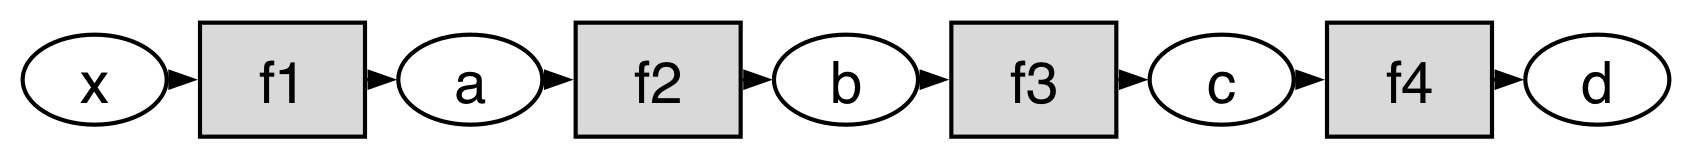

In [3]:
g = new_graph()

g.node('x', **tensor_node)
g.node('a', **tensor_node)
g.node('b', **tensor_node)
g.node('c', **tensor_node)
g.node('d', **tensor_node)
g.node('f1', **operation_node)
g.node('f2', **operation_node)
g.node('f3', **operation_node)
g.node('f4', **operation_node)

g.edge('x', 'f1')
g.edge('f1', 'a')
g.edge('a', 'f2')
g.edge('f2', 'b')
g.edge('b', 'f3')
g.edge('f3', 'c')
g.edge('c', 'f4')
g.edge('f4', 'd')

display_graph(g)

Using the intermediate variables, the chain rule becomes

$$
J_f(x) = J_{f_4}(c) J_{f_3}(b) J_{f_2}(a) J_{f_1}(x).
$$

The desired Jacobian is therefore a product of the primitive Jacobians. A direct algorithm would

+ Run the computational graph forward to compute the intermediate variables.
+ Compute the Jacobian of each primitive function.
+ Multiply the Jacobians in chain-rule order.

The intermediate Jacobians can be prohibitively large in machine-learning applications. Automatic differentiation avoids forming them explicitly.

## Forward-mode automatic differentiation

For a direction $v\in\mathbb{R}^n$, forward mode computes the *Jacobian-vector product* (JVP) $J_f(x)v$:

$$
J_f(x)v = J_{f_4}(c)\Big(J_{f_3}(b)\big(J_{f_2}(a)(J_{f_1}(x)v)\big)\Big).
$$

This calculation requires only the local JVP rule for each primitive. We write `primitive.jvp(z, w)` for the primitive's Jacobian at $z$ applied to the incoming tangent vector $w$. The vectors `v1`, `v2`, and `v3` below are the propagated tangents:

```python
a = f1(x)
v1 = f1.jvp(x, v)
b = f2(a)
v2 = f2.jvp(a, v1)
c = f3(b)
v3 = f3.jvp(b, v2)
d = f4(c)
Jfv = f4.jvp(c, v3)
```

The computational graph below overlays this tangent calculation on the ordinary value computation, often called the *primal* computation. Solid nodes and edges show the primal computation; dashed nodes and edges show the JVP calculation.

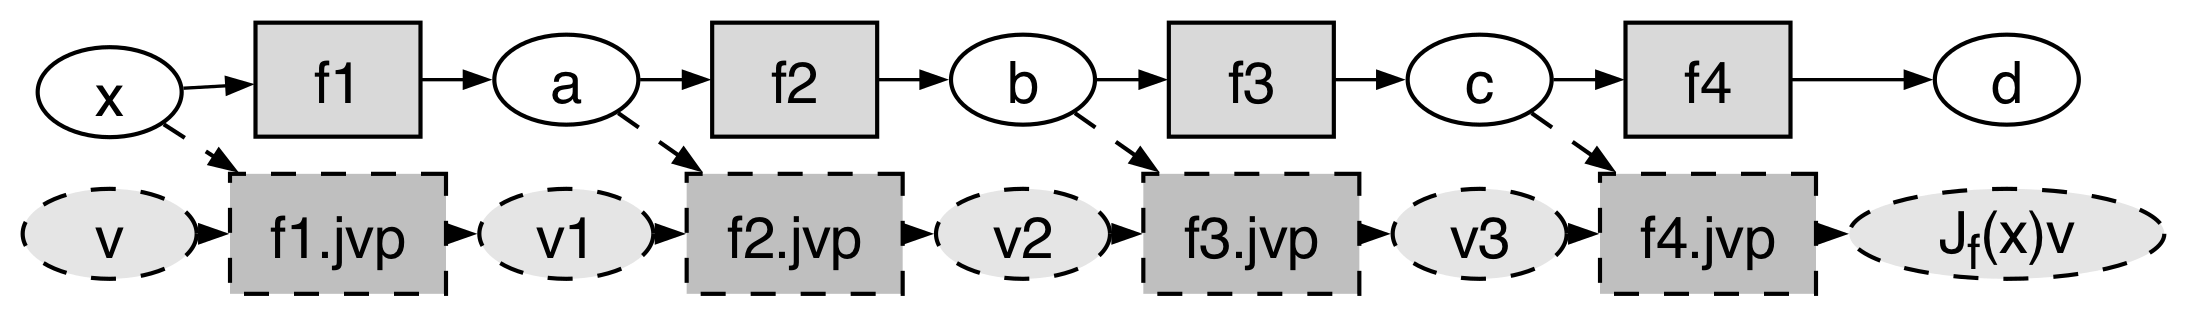

In [4]:
gf = g.copy()

gf.node('v', **derivative_tensor_node)
gf.node('v1', **derivative_tensor_node)
gf.node('v2', **derivative_tensor_node)
gf.node('v3', **derivative_tensor_node)
gf.node('Jfv', label='<J<sub>f</sub>(x)v>', **derivative_output_node)
gf.node('f1.jvp', **derivative_operation_node)
gf.node('f2.jvp', **derivative_operation_node)
gf.node('f3.jvp', **derivative_operation_node)
gf.node('f4.jvp', **derivative_operation_node)

gf.edge('x', 'f1.jvp', **derivative_edge)
gf.edge('v', 'f1.jvp', **derivative_edge)
gf.edge('f1.jvp', 'v1', **derivative_edge)
gf.edge('a', 'f2.jvp', **derivative_edge)
gf.edge('v1', 'f2.jvp', **derivative_edge)
gf.edge('f2.jvp', 'v2', **derivative_edge)
gf.edge('b', 'f3.jvp', **derivative_edge)
gf.edge('v2', 'f3.jvp', **derivative_edge)
gf.edge('f3.jvp', 'v3', **derivative_edge)
gf.edge('c', 'f4.jvp', **derivative_edge)
gf.edge('v3', 'f4.jvp', **derivative_edge)
gf.edge('f4.jvp', 'Jfv', **derivative_edge)

display_graph(gf)

Forward mode carries one tangent vector alongside each primal value and never forms a full intermediate Jacobian.

Choosing $v=e_j$, the $j$-th standard basis vector of $\mathbb{R}^n$, extracts one Jacobian column:

$$
J_f(x)e_j = \frac{\partial f(x)}{\partial x_j}.
$$

Computing every column requires $n$ forward sweeps. For a scalar loss, $n$ is the number of model parameters while $m=1$, so this cost scales with $n$, as coordinatewise finite differences do. Unlike finite differences, automatic differentiation has no step size and introduces no truncation error. Reverse mode exploits the small output dimension.


## Reverse-mode automatic differentiation

For a cotangent $u\in\mathbb{R}^m$, a vector of sensitivities attached to the output, reverse mode computes the *vector-Jacobian product* (VJP) $u^T J_f(x)$:

$$
u^T J_f(x) = \Big(\big((u^T J_{f_4}(c))J_{f_3}(b)\big)J_{f_2}(a)\Big)J_{f_1}(x).
$$

Suppose each primitive provides a local VJP rule. The vectors `u1`, `u2`, and `u3` below are the cotangents propagated from the output back toward the input:

```python
# Forward pass
a = f1(x)
b = f2(a)
c = f3(b)
d = f4(c)

# Backward pass
u1 = f4.vjp(c, u)
u2 = f3.vjp(b, u1)
u3 = f2.vjp(a, u2)
uTJf = f1.vjp(x, u3)
```

In the graph below, solid edges supply stored primal values to the VJP operations, while dashed edges carry cotangents backward.

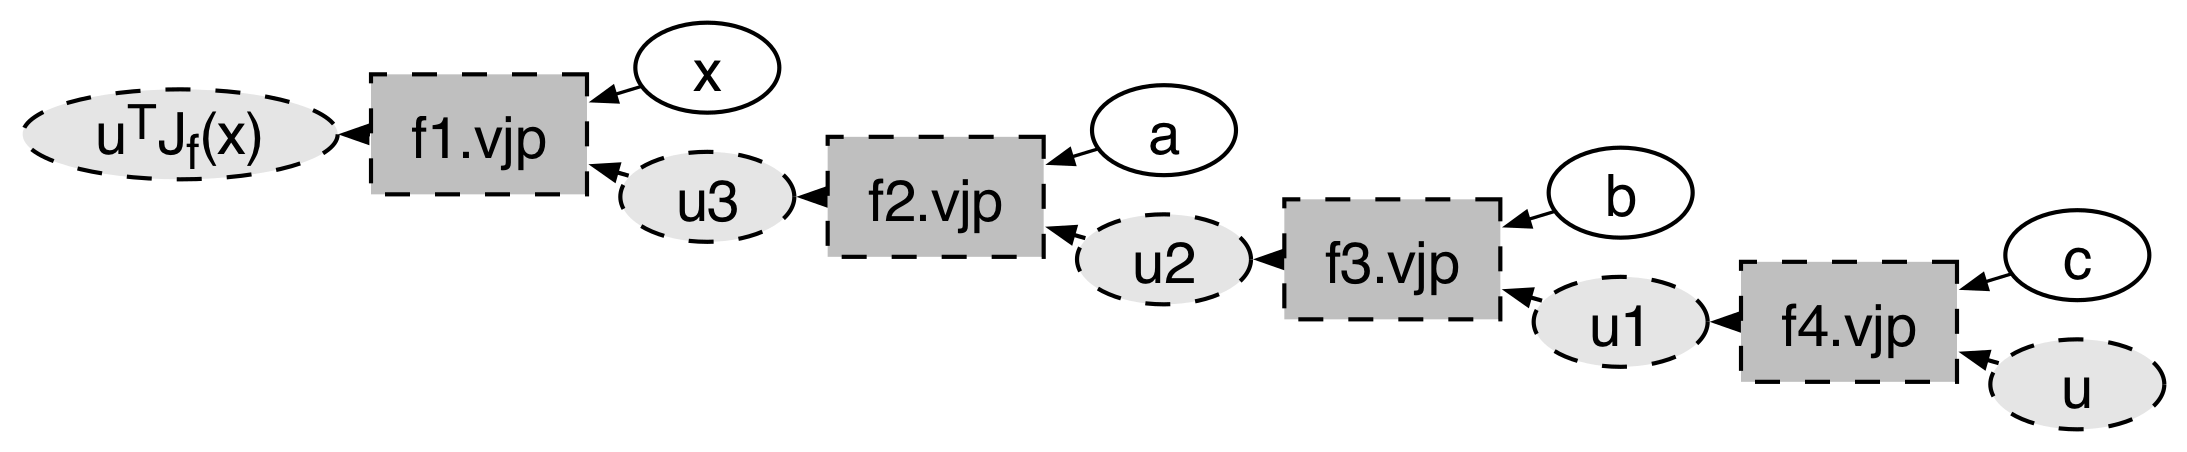

In [5]:
gb = new_graph(rankdir='RL')

gb.node('x', **tensor_node)
gb.node('a', **tensor_node)
gb.node('b', **tensor_node)
gb.node('c', **tensor_node)

gb.node('u', **derivative_tensor_node)
gb.node('u1', **derivative_tensor_node)
gb.node('u2', **derivative_tensor_node)
gb.node('u3', **derivative_tensor_node)

gb.node('uTJf', label='<u<sup>T</sup>J<sub>f</sub>(x)>', **derivative_output_node)

gb.node('f4.vjp', **derivative_operation_node)
gb.node('f3.vjp', **derivative_operation_node)
gb.node('f2.vjp', **derivative_operation_node)
gb.node('f1.vjp', **derivative_operation_node)

gb.edge('c', 'f4.vjp')
gb.edge('u', 'f4.vjp', **derivative_edge)
gb.edge('f4.vjp', 'u1', **derivative_edge)
gb.edge('b', 'f3.vjp')
gb.edge('u1', 'f3.vjp', **derivative_edge)
gb.edge('f3.vjp', 'u2', **derivative_edge)
gb.edge('a', 'f2.vjp')
gb.edge('u2', 'f2.vjp', **derivative_edge)
gb.edge('f2.vjp', 'u3', **derivative_edge)
gb.edge('x', 'f1.vjp')
gb.edge('u3', 'f1.vjp', **derivative_edge)
gb.edge('f1.vjp', 'uTJf', **derivative_edge)

display_graph(gb)

Reverse mode normally stores the intermediate primal values and traverses the graph once forward and once backward. Computing the entire Jacobian requires one forward evaluation followed by $m$ reverse sweeps, using $u=e_i$ for $i=1,\ldots,m$. For a scalar loss, $m=1$ and $u=1$, so one reverse sweep after the forward evaluation computes the gradient with respect to all $n$ parameters. In machine learning, this reverse-mode calculation is called *backpropagation*.

## Generic computational graphs

Branches require one additional local rule. Consider

$$
f(x) = x + x,
$$

implemented as

```python
def f(x):
    a = x + x
    return a
```

The primitive $\operatorname{add}:\mathbb{R}^n\times\mathbb{R}^n\to\mathbb{R}^n$ maps a pair of tensors to their sum. The map $\operatorname{fanout}:\mathbb{R}^n\to\mathbb{R}^n\times\mathbb{R}^n$ duplicates its input: $\operatorname{fanout}(x)=(x,x)$. Therefore,

$$
f = \operatorname{add} \circ \operatorname{fanout}.
$$

After identifying $\mathbb{R}^n\times\mathbb{R}^n$ with $\mathbb{R}^{2n}$, the fanout Jacobian is the $2n\times n$ matrix

$$
J_{\operatorname{fanout}}(x) = \begin{bmatrix} I_n \\ I_n \end{bmatrix}.
$$

Its JVP duplicates an incoming tangent. In reverse mode, cotangent contributions arriving through the two outgoing paths are added before propagation continues toward the input.

The same construction applies to

$$
f(x) = x^2 + x,
$$

implemented as:

```python
def f(x):
    a = x * x
    b = a + x
    return b
```

Here the square and the addition act componentwise. Let $\operatorname{sqr}(x)=x\odot x$, where $\odot$ denotes componentwise multiplication, and let $\operatorname{id}$ be the identity map. Then

$$
f = \operatorname{add} \circ (\operatorname{sqr}\times\operatorname{id}) \circ \operatorname{fanout}.
$$

The product map $\operatorname{sqr}\times\operatorname{id}:\mathbb{R}^n\times\mathbb{R}^n\to\mathbb{R}^n\times\mathbb{R}^n$ sends $(x_1,x_2)$ to $(\operatorname{sqr}(x_1),\operatorname{id}(x_2))$. Traversing operations in dependency order, applying local JVP/VJP rules, and adding cotangent contributions at branches extend automatic differentiation from chains to arbitrary DAGs.

## Further reading

Matt Johnson's [Autodidact](https://github.com/mattjj/autodidact) is a compact pedagogical implementation of Autograd. It illustrates the core operator-overloading ideas behind automatic-differentiation libraries such as `PyTorch` and `JAX`.